# **STEP 1: Load Dataset**

### The dataset was loaded using pandas and initial inspection was performed using head() and shape.

In [ ]:
import pandas as pd

# load dataset
df = pd.read_excel("/content/Flight_dataset[4039].xlsx")

# check data
print(df.head())
print(df.shape)


   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left   price  
0          Night           Mumbai  Economy      2.17        1.0  5953.0  
1        Morning           Mumbai  Economy      2.33        1.0  5953.0  
2  Early_Morning           Mumbai  Economy       NaN        1.0  5956.0  
3      Afternoon           Mumbai  Economy      2.25        1.0  5955.0  
4        Morning           Mumbai  Economy      2.33        1.0  5955.0  
(300153, 12)


# **STEP 2: Data Understanding**

The dataset contains flight booking details such as airline, source, destination, duration and price.

In [ ]:

# check columns
print(df.columns)

# info
df.info()

# missing values
print(df.isnull().sum())

Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300141 non-null  float64
 10  days_left         300148 non-null  float64
 11  price             300148 non-null  float64
dtypes: float64(3

# **STEP 3: Data Cleaning**

Missing values were removed to ensure a clean dataset for analysis.

In [ ]:
# remove duplicates
df = df.drop_duplicates()

# fill missing values (if any)
df = df.dropna()

## **STEP 4:  EDA**

**Ticket prices vary significantly across airlines**

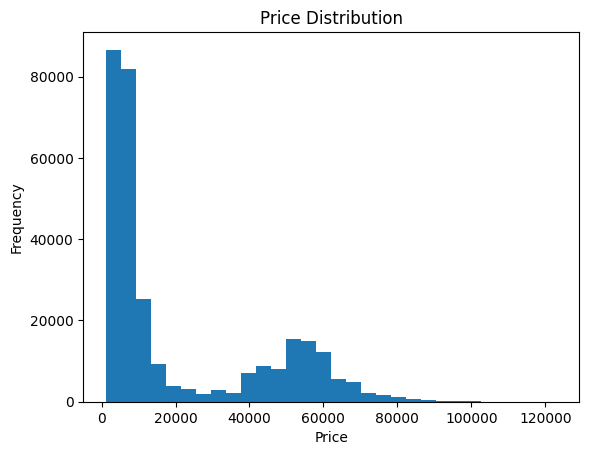

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['price'], bins=30)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Ticket prices are right-skewed, with most fares concentrated in lower ranges.

**Some airlines show consistently higher pricing**

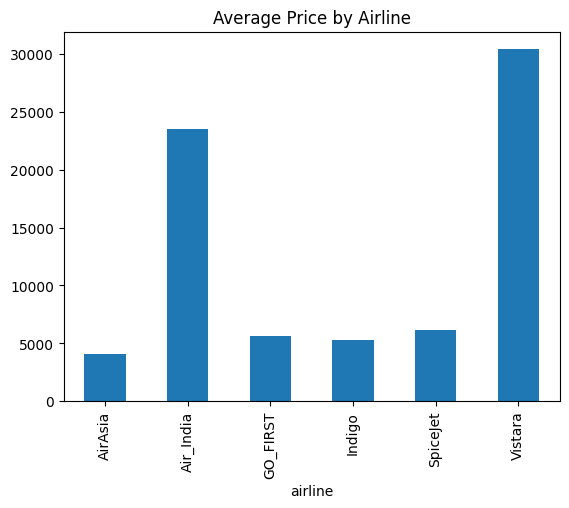

In [ ]:
df.groupby('airline')['price'].mean().plot(kind='bar')
plt.title('Average Price by Airline')
plt.show()

Vistara and Air India show higher average fares, while AirAsia offers lower average prices.

# **STEP 5: Hypothesis Testing**

H0: Airline has no effect on ticket price.

H1: Airline significantly affects ticket price.

Since p-value = 0.0 (<0.05), H0 was rejected.



In [ ]:
from scipy.stats import f_oneway

groups = [group['price'].values for name, group in df.groupby('airline')]
f_stat, p_value = f_oneway(*groups)

print(p_value)

0.0


# **STEP 6: Feature Engineering**

In [ ]:
df = df.drop_duplicates()
df = df.dropna()

df = df.drop(['Unnamed: 0', 'flight'], axis=1, errors='ignore')

print(df.head())
print(df.shape)

    airline source_city departure_time stops arrival_time destination_city  \
0  SpiceJet       Delhi        Evening  zero        Night           Mumbai   
1  SpiceJet       Delhi  Early_Morning  zero      Morning           Mumbai   
3   Vistara       Delhi        Morning  zero    Afternoon           Mumbai   
4   Vistara       Delhi        Morning  zero      Morning           Mumbai   
5   Vistara       Delhi        Morning  zero    Afternoon           Mumbai   

     class  duration  days_left   price  
0  Economy      2.17        1.0  5953.0  
1  Economy      2.33        1.0  5953.0  
3  Economy      2.25        1.0  5955.0  
4  Economy      2.33        1.0  5955.0  
5  Economy      2.33        1.0  5955.0  
(297921, 10)


# **STEP 7: Convert Categorical to Numeric**

In [ ]:
# convert text columns into numbers
df = pd.get_dummies(df, drop_first=True)

# check columns and shape
print(df.shape)
df.head()

(297921, 31)


,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,2.17,1.0,5953.0,False,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,True,True
1,2.33,1.0,5953.0,False,False,False,True,False,False,True,...,False,False,True,False,False,False,False,False,True,True
3,2.25,1.0,5955.0,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,True,True
4,2.33,1.0,5955.0,False,False,False,False,True,False,True,...,False,False,True,False,False,False,False,False,True,True
5,2.33,1.0,5955.0,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,True,True


# **STEP 8: Define Features and Target**

In [ ]:
# independent variables
X = df.drop('price', axis=1)

# dependent variable
y = df['price']

print(X.shape)
print(y.shape)

(297921, 30)
(297921,)


# **STEP 9: Train-Test Split**

The dataset was split into 80% training data and 20% testing data to evaluate model performance on unseen observations.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(238336, 30)
(59585, 30)


# **STEP 10: Model 1 – Ridge Regression**

Ridge Regression was selected as the first model to provide a strong baseline prediction method. It is an extension of Linear Regression that helps reduce overfitting and performs well when multiple features are present

In [ ]:
from sklearn.linear_model import Ridge

# first regression model
model1 = Ridge()

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

print("Model 1 completed")

Model 1 completed


# **STEP 11: Model 2 – Random Forest**

Random Forest Regressor was selected as the second model because it can capture complex non-linear relationships between variables. It is useful for handling mixed data and often provides strong predictive performance.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# second model
model2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Model 2 completed")

Model 2 completed


# **STEP 12: Evaluate Both Models**

Both regression models were evaluated using R² Score and RMSE. Random Forest outperformed Ridge Regression by achieving higher predictive performance and lower error. R² measures explained variance, while RMSE measures prediction error. Therefore, Random Forest was selected as the final model.

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def check_result(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(name)
    print("R2 Score :", round(r2,4))
    print("RMSE     :", round(rmse,2))
    print("--------------------")

check_result("Ridge Regression", y_test, y_pred1)
check_result("Random Forest", y_test, y_pred2)

Ridge Regression
R2 Score : 0.9121
RMSE     : 6763.7
--------------------
Random Forest
R2 Score : 0.9847
RMSE     : 2823.17
--------------------


# **STEP 13: Final Conclusion**

Two regression models were developed to predict flight prices. Ridge Regression provided strong baseline performance, while Random Forest delivered the best results with an R² score of 0.9847 and lower RMSE. This indicates that flight pricing is influenced by complex non-linear factors such as airline, class, route and booking timing.